# Tutorial 02 — Gasificador 0D: Pirólisis con alivio de presión (Semibatch)

**Equipo:** Gasificador de lecho fijo · **Modo:** 0D (N=1) · Semibatch (venteo controlado por presión)  
**Fenómeno:** Pirólisis de biomasa con acumulación de gas y alivio por válvula reguladora de presión  
**Prerrequisito:** Tutorial 01 — Gasificador 0D Batch

## Introducción

Este tutorial extiende el caso batch del Tutorial 01 añadiendo una **válvula de alivio de presión**
en la salida del reactor. El resto del sistema es idéntico: reactor 0D, biomasa seca, calefacción
externa a 800 °C, sin entrada de agente gasificante.

### Diferencia respecto al modo Batch

| Parámetro | Batch (Tutorial 01) | Semibatch (este tutorial) |
|-----------|--------------------|-----------------------------|
| `v_gas_in` | `None` | `None` |
| `v_out`    | `0.0` (sellado) | `> 0` (venteo activo) |
| Comportamiento de la salida | Sistema sellado: P sube libremente | Válvula cerrada hasta que P > P_out; abre proporcionalmente al exceso de presión |

### Ley de la válvula de alivio

En semibatch (`v_out > 0`), la velocidad de salida del gas se calcula como:

$$v_{out}(t) = \max\!\left(0,\; \frac{P(t) - P_{out}}{P_{out}}\right) \cdot v_{out}$$

donde `v_out` [m/s] es el parámetro pasado a `build_bc_config` y actúa como la velocidad
máxima de venteo (apertura total de válvula cuando P = 2·P_out).

| Condición | Comportamiento |
|-----------|----------------|
| $P = P_{out}$ | Válvula cerrada ($v_{out,actual} = 0$) |
| $P = 2 \cdot P_{out}$ | Venteo máximo ($v_{out,actual} = v_{out}$) |
| `v_out` pequeño | Válvula restrictiva → P sube mucho antes de ventilar |
| `v_out` grande | Válvula permeable → P ≈ P_out en todo momento (≈ batch sellado a baja P) |

### Dos casos comparados

| Caso | `v_out` [m/s] | Descripción física |
|------|---------------|-----------------------|
| **A — Venteo lento** | 0.01 | Válvula restrictiva. El gas producido se acumula; la presión puede subir varios bar. |
| **B — Venteo rápido** | 0.50 | Válvula permeable. P se mantiene próxima a la atmosférica. |

### Qué observar

1. **Presión** ($P$ vs $t$): cuánto sube en el caso lento; cómo permanece casi plana en el rápido.
2. **Velocidad de venteo** ($v_{out,actual}$ vs $t$): el perfil temporal de apertura de la válvula.
3. **Temperaturas** ($T_g$, $T_s$ vs $t$): el gas acumulado tiene mayor masa → diferente dinámica térmica.
4. **Composición del gas**: las fracciones molares son similares (mismas reacciones), pero las concentraciones absolutas [mol/m³] serán mucho mayores en el caso lento.

In [45]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt

# Ajustar ruta al raíz del proyecto (test/gasifier/ → ../../)
ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from src.io.fuels_reader import read_fueldb
from src.units.gasifier.config.gas_props    import build_gas_prop_config, GASIFIER_GAS_SPECIES
from src.units.gasifier.config.solid_props  import build_solid_prop_config
from src.units.gasifier.config.transport    import build_transport_config
from src.units.gasifier.config.thermal_bc   import build_thermal_bc_config
from src.units.gasifier.config.boundary_c   import build_bc_config
from src.units.gasifier.config.initial_c    import build_initial_c_config
from src.solvers.runner_gasifier            import run_step
from src.postprocessing.gasifier_balances   import check_balances, display_balances
from src.postprocessing.gasifier_plots      import (
    plot_temperatures, plot_solid_evolution,
    plot_gas_composition, plot_pressure,
)

print(f"ROOT: {ROOT}")

ROOT: C:\Users\MiguelCamaraSanz\OneDrive - Fundacion CIRCE\GITHUB\ProSimNet-gasifier


## 1. Bases de datos y propiedades del combustible

In [46]:
# Rutas a bases de datos
FUEL_PATH = os.path.join(ROOT, "materials", "fuels", "softwood_spruce.yaml")
GAS_DB    = os.path.join(ROOT, "materials", "fluids", "gasdb.txt")
SOLID_DB  = os.path.join(ROOT, "materials", "solids", "soliddb.txt")

# Carga del combustible
fuel_config = read_fueldb(FUEL_PATH)

# Resumen del combustible cargado
rho_p = float(fuel_config["physical"]["rho_particle"])   # [kg/m³]
dp0   = float(fuel_config["physical"]["dp_initial"])     # [m]
print(f"Combustible : {fuel_config['description']}")
print(f"ρ_partícula : {rho_p:.0f} kg/m³")
print(f"dp_inicial  : {dp0*1000:.1f} mm")

Combustible : Softwood (spruce) for fixed-bed updraft gasification
ρ_partícula : 430 kg/m³
dp_inicial  : 10.0 mm


## 2. Geometría y condiciones de operación

Mismo reactor del Tutorial 01: tubo de ≈ 785 cm³ calentado externamente.
Geometría y carga de sólido idénticas para que la comparación sea directa.

In [47]:
# ── Geometría ─────────────────────────────────────────────────────────────────
N  = 1       # Número de celdas → modelo 0D (volumen perfectamente mezclado)
L  = 0.10    # [m]  longitud del reactor
Di = 0.10    # [m]  diámetro interno
Do = 0.114   # [m]  diámetro externo (e_pared = 7 mm, acero inox 316L)

dz     = L / N                     # [m]   tamaño de celda
Ai     = 0.25 * np.pi * Di**2      # [m²]  sección transversal interna
Pi     = np.pi * Di                # [m]   perímetro interno
Po     = np.pi * Do                # [m]   perímetro externo
e_wall = (Do - Di) / 2             # [m]   espesor de pared

# ── Condiciones de operación ──────────────────────────────────────────────────
epsi_r = 0.60       # [-]   porosidad del lecho (fracción de huecos gas/volumen lecho)
P_out  = 1.01325    # [bar] presión de referencia (salida de la válvula de alivio)

# ── Carga inicial de biomasa ──────────────────────────────────────────────────
mc_wb       = 0.15                                          # [-]         contenido de humedad base húmeda
rho_bio_dry = rho_p * (1 - epsi_r)                          # [kg/m³_bed] biomasa seca en lecho
rho_moi_0   = rho_bio_dry * mc_wb / (1 - mc_wb)             # [kg/m³_bed] humedad inicial
rho_bio_0   = rho_bio_dry                                   # [kg/m³_bed] biomasa inicial
rho_char_0  = 1e-6                                          # [kg/m³_bed] traza de char inicial

# Densidad de referencia del char (para modelo de partícula decreciente SCM)
rho_char0 = fuel_config["pyrolysis_yields"]["char"] * rho_p * (1 - epsi_r)

print(f"Geometría:")
print(f"  N = {N} celdas → modelo 0D")
print(f"  V_reactor = {Ai*L*1e6:.1f} cm³  (Di={Di*100:.0f} cm, L={L*100:.0f} cm)")
print(f"\nCarga inicial de sólido:")
print(f"  ρ_biomasa  = {rho_bio_0:.1f} kg/m³_bed")
print(f"  ρ_humedad  = {rho_moi_0:.1f} kg/m³_bed  ({mc_wb*100:.0f} % wb)")
print(f"  ρ_char_ini = {rho_char_0:.1e} kg/m³_bed  (traza)")

Geometría:
  N = 1 celdas → modelo 0D
  V_reactor = 785.4 cm³  (Di=10 cm, L=10 cm)

Carga inicial de sólido:
  ρ_biomasa  = 172.0 kg/m³_bed
  ρ_humedad  = 30.4 kg/m³_bed  (15 % wb)
  ρ_char_ini = 1.0e-06 kg/m³_bed  (traza)


## 3. Condiciones iniciales del gas

Igual que en el Tutorial 01: N₂ puro a temperatura ambiente (300 K) y presión atmosférica.

In [48]:
T_init = 300.0    # [K] temperatura inicial de gas y sólido (≈ 27 °C)

species = list(GASIFIER_GAS_SPECIES)   # ['CO','CO2','H2O','H2','O2','CH4','C2H4','tar','N2']
nc      = len(species)                 # 9 especies

y0 = np.zeros(nc)
y0[species.index("N2")] = 1.0    # 100 % N₂ al inicio

print(f"Temperatura inicial: {T_init:.1f} K ({T_init-273.15:.1f} °C)")
print(f"Composición inicial: 100 % N₂")
print(f"Presión inicial    : {P_out:.5f} bar")

Temperatura inicial: 300.0 K (26.9 °C)
Composición inicial: 100 % N₂
Presión inicial    : 1.01325 bar


## 4. Condición térmica (común a ambos casos)

Pared a temperatura fija de 800 °C, igual que en el Tutorial 01.
La condición térmica no varía entre los dos casos — solo cambia el modo de la salida del gas.

In [49]:
T_wall   = 1073.15    # [K] = 800 °C — temperatura de la pared exterior
k_wall   = 16.5       # [W/m/K]  conductividad térmica acero inoxidable 316L
rho_wall = 7950.0     # [kg/m³]  densidad acero inoxidable 316L
Cp_wall  = 510.0      # [J/kg/K] calor específico acero inoxidable 316L

tbc_cfg = build_thermal_bc_config(
    mode     = "fixed_twall",
    Di       = Di,
    Do       = Do,
    e_wall   = e_wall,
    T_wall   = T_wall,
    k_wall   = k_wall,
    rho_wall = rho_wall,
    Cp_wall  = Cp_wall,
)

print(f"BC térmica: pared fija  T_wall = {T_wall:.2f} K ({T_wall-273.15:.1f} °C)")
print(f"Material  : k={k_wall} W/m/K  ρ={rho_wall:.0f} kg/m³  Cp={Cp_wall:.0f} J/kg/K")

BC térmica: pared fija  T_wall = 1073.15 K (800.0 °C)
Material  : k=16.5 W/m/K  ρ=7950 kg/m³  Cp=510 J/kg/K


## 5. Propiedades y modelo de transporte

In [50]:
# ── Propiedades del gas (modo polinomial: Cp, µ, k dependientes de T) ──────────
prop_gas  = build_gas_prop_config(fuel_config=fuel_config, mode="polynomial", db_path=GAS_DB)
gas_T_ref = float(np.min(np.asarray(prop_gas["Tref"])))   # [K] temperatura de referencia de entalpía
MW_arr    = np.asarray(prop_gas["MW"])                     # [kg/mol]

# ── Propiedades del sólido (Cp_fns y h_fns como funciones de T) ────────────────
solid_config = build_solid_prop_config(fuel_config)

# ── Modelo de transporte: constante ────────────────────────────────────────────
trans_cfg = build_transport_config(
    mode   = "constant",
    N      = N,
    n_comp = nc,
    h_bed  = 80.0,    # [W/m²/K] coeficiente gas-partícula
    h_wall = 20.0,    # [W/m²/K] coeficiente gas-pared
)

print(f"gas_T_ref = {gas_T_ref:.2f} K  (referencia de entalpía)")
print(f"Transporte: constante  (h_bed=80, h_wall=20 W/m²/K)")

gas_T_ref = 298.00 K  (referencia de entalpía)
Transporte: constante  (h_bed=80, h_wall=20 W/m²/K)


## 6. Vector de estado inicial (sv0)

El mismo sv0 sirve para los dos casos, ya que las condiciones iniciales son idénticas.

```
sv0 = [C(nc×N), ρ_s(3×N), Hg(N), Ts(N), Q_mt_acc(N), Q_rxn_acc(N), Q_gs_acc(N)]
      └── 9N ──┘└── 3N ──┘└─ N ┘└─ N ┘└────── N ─────┘└────── N ──┘└────── N ──┘
                                                                    total = 17×N
```

Para N=1: `sv0.shape = (17,)`

In [51]:
init_cfg = build_initial_c_config(
    P_init            = P_out,
    Tg_init           = T_init,
    Ts_init           = T_init,
    y_init            = y0,
    rho_biomass_init  = rho_bio_0,
    rho_char_init     = rho_char_0,
    rho_moisture_init = rho_moi_0,
    n_comp            = nc,
    N                 = N,
    prop_gas          = prop_gas,
    epsi_r            = epsi_r,
    gas_T_ref         = gas_T_ref,
    Tw_init           = None,    # Sin modelo dinámico de pared
)

sv0 = init_cfg["sv0"]
print(f"sv0.shape = {sv0.shape}   ({sv0.shape[0] // N} × {N} = {sv0.shape[0]} DOFs)")

sv0.shape = (17,)   (17 × 1 = 17 DOFs)


## 7. Parámetros base (comunes a ambos casos)

El diccionario `params_base` contiene todos los parámetros compartidos. La clave `bc_config`
se añadirá por separado en cada caso, ya que es el único parámetro que cambia.

In [52]:
params_base = {
    # Geometría
    "n_comp" : nc,
    "N"      : N,
    "dz"     : dz,
    "Ai"     : Ai,
    "Di"     : Di,
    "Pi"     : Pi,
    "Po"     : Po,
    # Propiedades del gas
    "prop_gas"   : prop_gas,
    "MW"         : MW_arr,
    "gas_T_ref"  : gas_T_ref,
    # Configuraciones compartidas
    "trans_config"     : trans_cfg,
    "thermal_bc_config": tbc_cfg,
    "energy"           : True,
    # Específico del gasificador
    "epsi_r"      : epsi_r,
    "dp0"         : dp0,
    "rho_char0"   : rho_char0,
    "fuel_config" : fuel_config,
    "solid_config": solid_config,
    "species"     : species,
    # bc_config no está aquí → se añade en cada caso
}

---
## 8.A — Caso A: Venteo lento (`v_out = 0.01 m/s`)

La válvula de alivio tiene una capacidad muy limitada. El gas producido por la pirólisis
se acumula en el reactor y la presión puede subir varios bar antes de que la tasa de venteo
sea suficiente para compensar la producción.

**Nota sobre la fórmula:** con `v_out = 0.01` m/s, la válvula solo alcanza su apertura
máxima cuando $P = 2 \cdot P_{out} \approx 2$ bar. Para $P = 1.1 \cdot P_{out}$,
$v_{out,actual} = 0.001$ m/s — una décima parte del máximo.

In [53]:
v_vent_lento = 0.01    # [m/s] velocidad máxima de venteo — válvula restrictiva

bc_cfg_A = build_bc_config(
    n_comp    = nc,
    P_out_bar = P_out,
    v_gas_in  = None,
    v_out     = v_vent_lento,   # venteo: v_out actúa como velocidad máxima de alivio
)

T_MAX = 600.0    # [s]
params_A = {**params_base, "bc_config": bc_cfg_A}

print("=" * 60)
print(f"Caso A — Venteo lento   v_out = {v_vent_lento} m/s")
print("=" * 60)

t_A, y_hist_A, gasifier_A = run_step(
    sv0           = sv0,
    t_max         = T_MAX,
    params        = params_A,
    rtol          = 1e-5,
    atol          = 1e-7,
    n_sec         = 5,
    show_progress = True,
)

if t_A[-1] < T_MAX * 0.99:
    print(f"\n⚠  El solver no alcanzó t_max. Último t = {t_A[-1]:.1f} s")
else:
    print(f"\n✓  Completado. t_final = {t_A[-1]:.1f} s  |  pasos = {len(t_A)}")
    P_max_A = float(np.max(gasifier_A._P_results[:, 0]))
    print(f"   P_max    = {P_max_A:.4f} bar  ({P_max_A/P_out:.2f} × P_out)")
    print(f"   Tg_final = {gasifier_A._Tg_results[-1, 0]:.1f} K  "
          f"({gasifier_A._Tg_results[-1, 0]-273.15:.1f} °C)")
    print(f"   Ts_final = {gasifier_A._Ts_results[-1, 0]:.1f} K  "
          f"({gasifier_A._Ts_results[-1, 0]-273.15:.1f} °C)")

Caso A — Venteo lento   v_out = 0.01 m/s


gasifier:   0%|          | 0.0/600 s [00:00<?, ?s/s]


✓  Completado. t_final = 600.0 s  |  pasos = 3001
   P_max    = 3.6032 bar  (3.56 × P_out)
   Tg_final = 630.0 K  (356.8 °C)
   Ts_final = 618.9 K  (345.7 °C)


### Resultados — Caso A

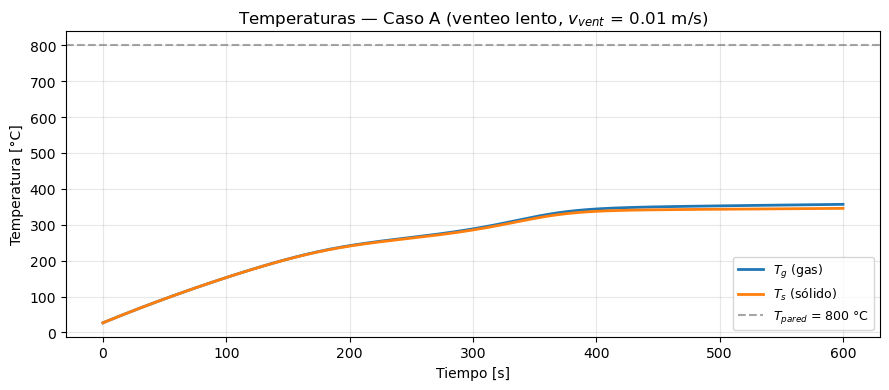

In [54]:
fig, ax = plot_temperatures(
    gasifier_A,
    T_ref       = T_wall,
    T_ref_label = f"$T_{{pared}}$ = {T_wall - 273.15:.0f} °C",
)
ax.set_title(f"Temperaturas — Caso A (venteo lento, $v_{{vent}}$ = {v_vent_lento} m/s)")
plt.show()

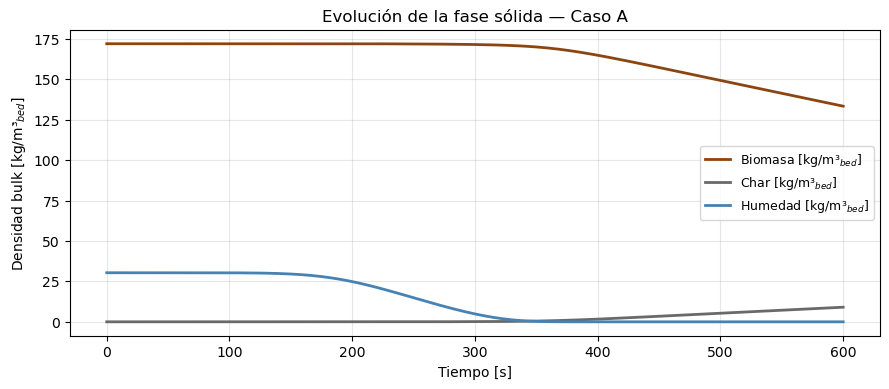

In [55]:
fig, ax = plot_solid_evolution(gasifier_A)
ax.set_title(f"Evolución de la fase sólida — Caso A")
plt.show()

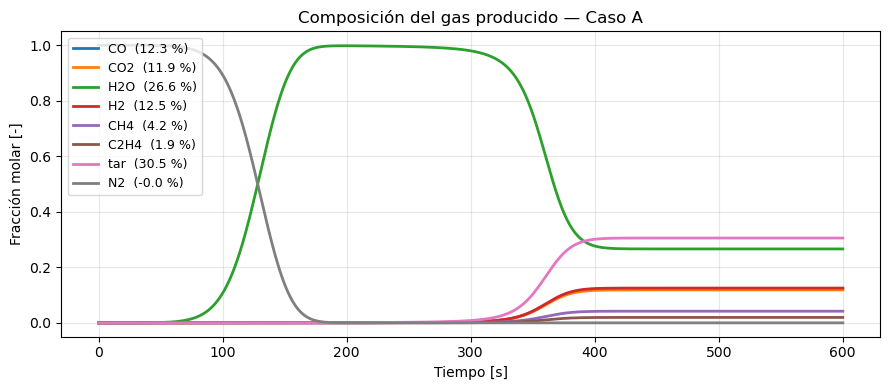

In [56]:
fig, ax = plot_gas_composition(gasifier_A)
ax.set_title(f"Composición del gas producido — Caso A")
plt.show()

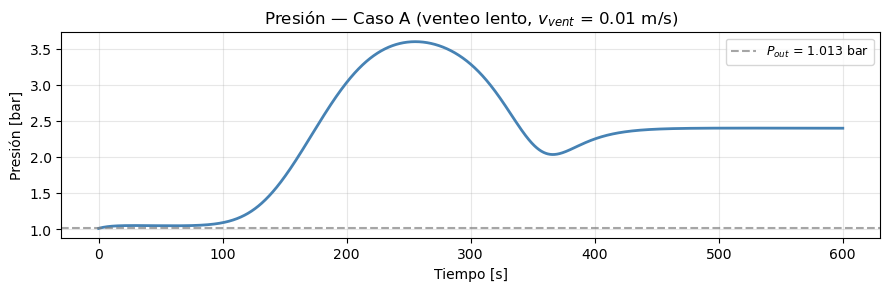

In [57]:
fig, ax = plot_pressure(gasifier_A)
ax.axhline(P_out, ls="--", color="gray", alpha=0.7, label=f"$P_{{out}}$ = {P_out:.3f} bar")
ax.legend(fontsize=9)
ax.set_title(f"Presión — Caso A (venteo lento, $v_{{vent}}$ = {v_vent_lento} m/s)")
plt.show()

---
## 8.B — Caso B: Venteo rápido (`v_out = 0.50 m/s`)

La válvula tiene una capacidad muy elevada. Cualquier pequeño exceso de presión sobre $P_{out}$
genera un caudal de venteo suficiente para evacuar el gas producido inmediatamente.
Se espera que la presión permanezca muy próxima a la atmosférica en todo momento.

**Único cambio respecto al Caso A:** `v_out = 0.50 m/s` en lugar de `0.01 m/s`.

In [58]:
v_vent_rapido = 0.50    # [m/s] velocidad máxima de venteo — válvula permeable

bc_cfg_B = build_bc_config(
    n_comp    = nc,
    P_out_bar = P_out,
    v_gas_in  = None,
    v_out     = v_vent_rapido,  # venteo: v_out actúa como velocidad máxima de alivio
)

params_B = {**params_base, "bc_config": bc_cfg_B}

print("=" * 60)
print(f"Caso B — Venteo rápido  v_out = {v_vent_rapido} m/s")
print("=" * 60)

t_B, y_hist_B, gasifier_B = run_step(
    sv0           = sv0,
    t_max         = T_MAX,
    params        = params_B,
    rtol          = 1e-5,
    atol          = 1e-7,
    n_sec         = 5,
    show_progress = True,
)

if t_B[-1] < T_MAX * 0.99:
    print(f"\n⚠  El solver no alcanzó t_max. Último t = {t_B[-1]:.1f} s")
else:
    print(f"\n✓  Completado. t_final = {t_B[-1]:.1f} s  |  pasos = {len(t_B)}")
    P_max_B = float(np.max(gasifier_B._P_results[:, 0]))
    print(f"   P_max    = {P_max_B:.4f} bar  ({P_max_B/P_out:.4f} × P_out)")
    print(f"   Tg_final = {gasifier_B._Tg_results[-1, 0]:.1f} K  "
          f"({gasifier_B._Tg_results[-1, 0]-273.15:.1f} °C)")
    print(f"   Ts_final = {gasifier_B._Ts_results[-1, 0]:.1f} K  "
          f"({gasifier_B._Ts_results[-1, 0]-273.15:.1f} °C)")

Caso B — Venteo rápido  v_out = 0.5 m/s


gasifier:   0%|          | 0.0/600 s [00:00<?, ?s/s]


✓  Completado. t_final = 600.0 s  |  pasos = 3001
   P_max    = 1.1724 bar  (1.1570 × P_out)
   Tg_final = 630.0 K  (356.9 °C)
   Ts_final = 618.9 K  (345.7 °C)


### Resultados — Caso B

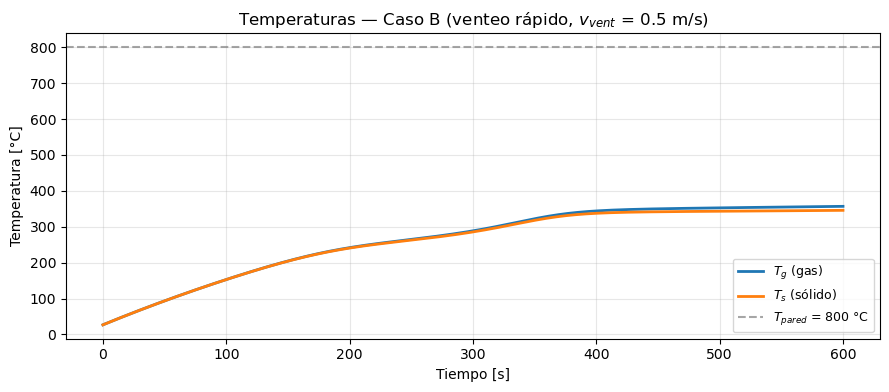

In [59]:
fig, ax = plot_temperatures(
    gasifier_B,
    T_ref       = T_wall,
    T_ref_label = f"$T_{{pared}}$ = {T_wall - 273.15:.0f} °C",
)
ax.set_title(f"Temperaturas — Caso B (venteo rápido, $v_{{vent}}$ = {v_vent_rapido} m/s)")
plt.show()

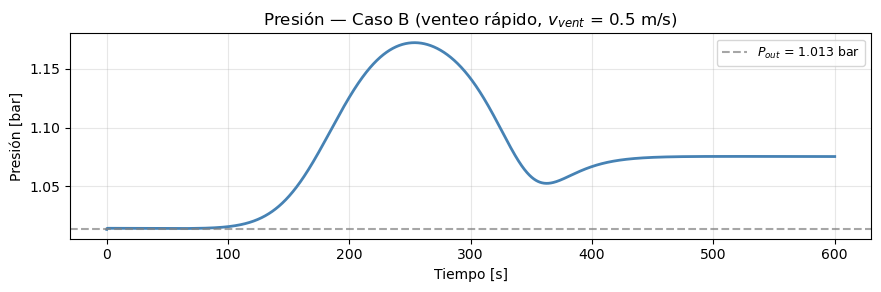

In [60]:
fig, ax = plot_pressure(gasifier_B)
ax.axhline(P_out, ls="--", color="gray", alpha=0.7, label=f"$P_{{out}}$ = {P_out:.3f} bar")
ax.legend(fontsize=9)
ax.set_title(f"Presión — Caso B (venteo rápido, $v_{{vent}}$ = {v_vent_rapido} m/s)")
plt.show()

---
## 9. Comparación venteo lento vs venteo rápido

Las gráficas siguientes superponen los dos casos para evidenciar el efecto de la capacidad
de venteo en cada variable del proceso.

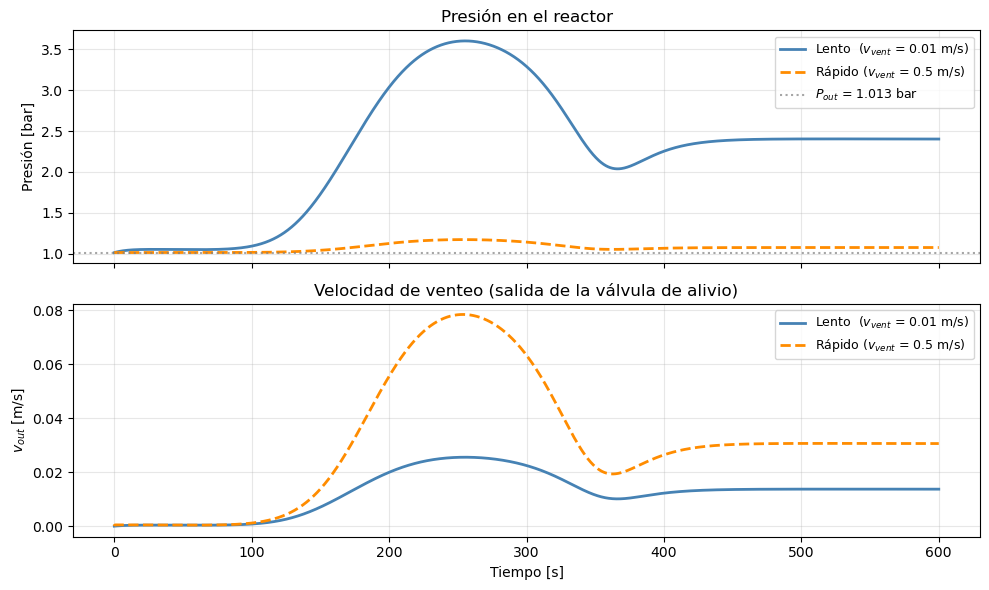

In [61]:
# ── Presión y velocidad de venteo ────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

# — Presión —
axes[0].plot(t_A, gasifier_A._P_results[:, 0],
             lw=2, color="steelblue",  label=f"Lento  ($v_{{vent}}$ = {v_vent_lento} m/s)")
axes[0].plot(t_B, gasifier_B._P_results[:, 0],
             lw=2, color="darkorange", label=f"Rápido ($v_{{vent}}$ = {v_vent_rapido} m/s)",
             ls="--")
axes[0].axhline(P_out, ls=":", color="gray", alpha=0.7, label=f"$P_{{out}}$ = {P_out:.3f} bar")
axes[0].set_ylabel("Presión [bar]")
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)
axes[0].set_title("Presión en el reactor")

# — Velocidad de venteo (v_out) —
axes[1].plot(t_A, gasifier_A._v_out_results,
             lw=2, color="steelblue",  label=f"Lento  ($v_{{vent}}$ = {v_vent_lento} m/s)")
axes[1].plot(t_B, gasifier_B._v_out_results,
             lw=2, color="darkorange", label=f"Rápido ($v_{{vent}}$ = {v_vent_rapido} m/s)",
             ls="--")
axes[1].set_xlabel("Tiempo [s]")
axes[1].set_ylabel("$v_{out}$ [m/s]")
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)
axes[1].set_title("Velocidad de venteo (salida de la válvula de alivio)")

fig.tight_layout()
plt.show()

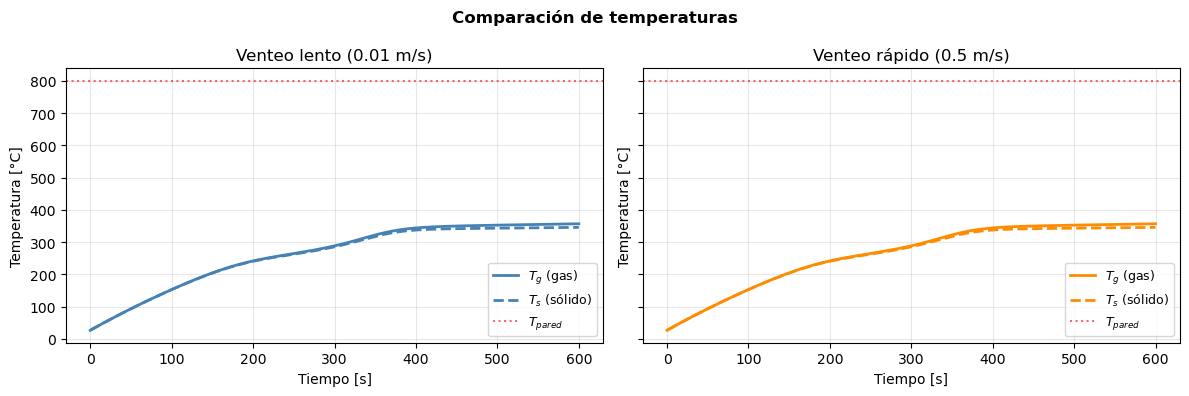

In [62]:
# ── Temperaturas de gas y sólido ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

for ax, col, label, color in [
    (axes[0], gasifier_A, f"Venteo lento ({v_vent_lento} m/s)",  "steelblue"),
    (axes[1], gasifier_B, f"Venteo rápido ({v_vent_rapido} m/s)", "darkorange"),
]:
    t_    = col._t_results
    Tg_C  = col._Tg_results[:, 0] - 273.15
    Ts_C  = col._Ts_results[:, 0] - 273.15
    ax.plot(t_, Tg_C, lw=2, color=color,         label="$T_g$ (gas)")
    ax.plot(t_, Ts_C, lw=2, color=color, ls="--", label="$T_s$ (sólido)")
    ax.axhline(T_wall - 273.15, ls=":", color="red", alpha=0.6, label="$T_{pared}$")
    ax.set_xlabel("Tiempo [s]")
    ax.set_ylabel("Temperatura [°C]")
    ax.set_title(label)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

fig.suptitle("Comparación de temperaturas", fontweight="bold")
fig.tight_layout()
plt.show()

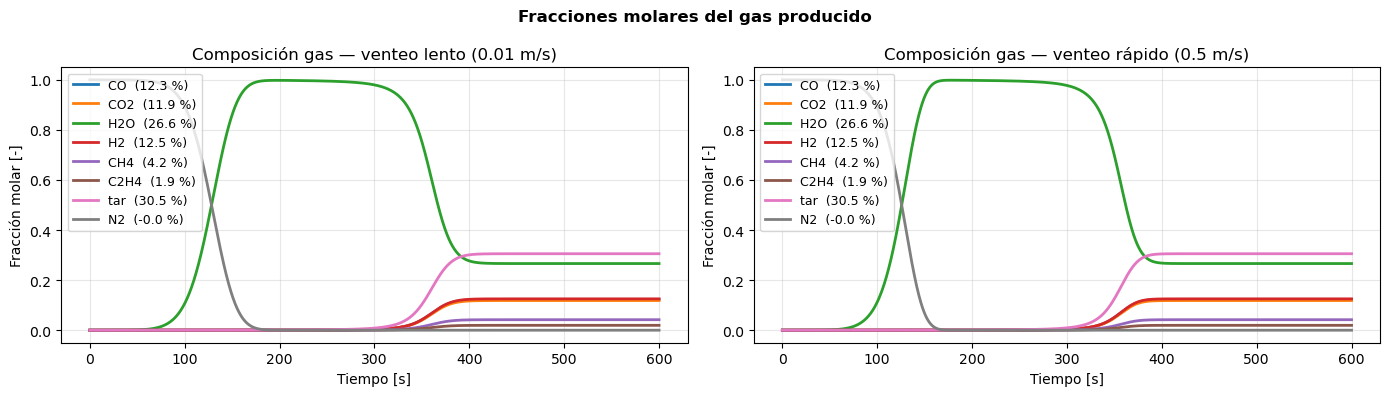

In [63]:
# ── Composición del gas — fracciones molares ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

_, _ = plot_gas_composition(gasifier_A, ax=axes[0])
axes[0].set_title(f"Composición gas — venteo lento ({v_vent_lento} m/s)")

_, _ = plot_gas_composition(gasifier_B, ax=axes[1])
axes[1].set_title(f"Composición gas — venteo rápido ({v_vent_rapido} m/s)")

fig.suptitle("Fracciones molares del gas producido", fontweight="bold")
fig.tight_layout()
plt.show()

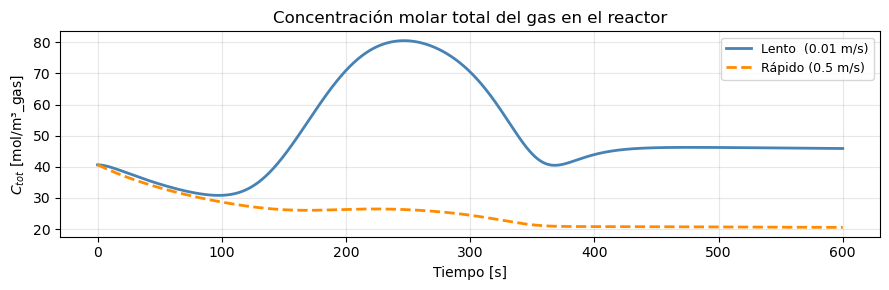

Ctot máxima — Caso A (lento):  80.5 mol/m³
Ctot máxima — Caso B (rápido): 40.6 mol/m³


In [64]:
# ── Concentración molar total del gas ─────────────────────────────────────────
# La diferencia entre casos es máxima aquí: más presión → más mol/m³
R_GAS = 8.31446261815324   # [J/mol/K]

# Concentración total = P [Pa] / (R · Tg [K])
Ctot_A = (gasifier_A._P_results[:, 0] * 1e5) / (R_GAS * gasifier_A._Tg_results[:, 0])
Ctot_B = (gasifier_B._P_results[:, 0] * 1e5) / (R_GAS * gasifier_B._Tg_results[:, 0])

fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(t_A, Ctot_A, lw=2, color="steelblue",  label=f"Lento  ({v_vent_lento} m/s)")
ax.plot(t_B, Ctot_B, lw=2, color="darkorange", label=f"Rápido ({v_vent_rapido} m/s)", ls="--")
ax.set_xlabel("Tiempo [s]")
ax.set_ylabel("$C_{tot}$ [mol/m³_gas]")
ax.set_title("Concentración molar total del gas en el reactor")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

print(f"Ctot máxima — Caso A (lento):  {float(np.max(Ctot_A)):.1f} mol/m³")
print(f"Ctot máxima — Caso B (rápido): {float(np.max(Ctot_B)):.1f} mol/m³")

---
## 10. Verificación de balances

Los balances deben cerrarse en los dos casos. El modo de venteo no rompe los balances:
en el Caso A hay más flujo de salida tardío; en el B la salida ocurre desde el principio.

In [65]:
print(f"{'='*60}")
print(f"Balances — Caso A (venteo lento, v_out = {v_vent_lento} m/s)")
print(f"{'='*60}")
balances_A = check_balances(gasifier_A, params_A, verbose=False)
display_balances(balances_A)

Balances — Caso A (venteo lento, v_out = 0.01 m/s)
── ★ Masa total [kg/m³] ──────────────────────────────────────────────


,Valor [kg/m³],Tipo
Término,,
Δm_gas,+2.0406e-01,
Δm_sólido,-5.9938e+01,
Flujo_masa_neto,-5.9734e+01,
★ Cierre,+1.6714e-05,0.000 % ✓ OK



── ~ Especies gas [mol/m³]  (Fuente_rxn = producida/consumida por reacciones — residual físico esperado ≠ 0) ─


,ΔC_i [mol/m³],Flujo_neto [mol/m³],~ Fuente_rxn [mol/m³]
CO,+3.3893e+00,-1.0968e+02,+1.1307e+02
CO2,+3.2621e+00,-1.0556e+02,+1.0882e+02
H2O,+7.3263e+00,-1.9219e+03,+1.9293e+03
H2,+3.4459e+00,-1.1151e+02,+1.1496e+02
O2,-2.3191e-20,+1.3487e-18,-1.3719e-18
CH4,+1.1547e+00,-3.7366e+01,+3.8521e+01
C2H4,+5.3650e-01,-1.7361e+01,+1.7898e+01
tar,+8.4070e+00,-2.7206e+02,+2.8046e+02
N2,-2.4373e+01,-2.4373e+01,-6.8306e-04



── ~ Masa sólida [kg/m³]  (S_rxn = masa transformada por reacciones — residual físico esperado ≠ 0) ──────


...

,Valor [J/m³],Nota
Término,,
ΔHg,+8.4795e+05,acumulación gas
Fh_conv_neto,-1.2516e+08,exacto
Q_gs (gas→sólido),+2.5637e+08,acum. ODE — exacto
Q_wall (pared→gas),+2.5730e+08,thermal_bc
Q_mt (sól→gas),+1.2507e+08,acum. ODE — exacto
★ Cierre_Hg,+1.4439e+01,0.000 % ✓ OK



── ★ Energía sólido  Ts [J/m³] ──────────────────────────────────────────


,Valor [J/m³],Nota
Término,,
"ΔHs [∫Cp dT, exacto]",+8.1805e+07,Σ ρⱼ·H_j(Ts)
Q_gs (gas→sólido),+2.5637e+08,acum. ODE — exacto
Q_rxn (exacto),-1.7456e+08,acum. ODE — exacto
★ Cierre_Hs,-2.5955e+02,-0.000 % ✓ OK



── ★ Balance global  Hg+Hs [J/m³] ──────────────────────────────────────


,Valor [J/m³],Nota
Término,,
ΔHg + ΔHs,+8.2653e+07,acumulación total
Fh_conv_neto,-1.2516e+08,exacto
Q_wall,+2.5730e+08,thermal_bc
Q_rxn (exacto),-1.7456e+08,acum. ODE
Q_mt (exacto),+1.2507e+08,acum. ODE
★ Cierre global,-2.4511e+02,-0.000 % ✓ OK


In [66]:
print(f"{'='*60}")
print(f"Balances — Caso B (venteo rápido, v_out = {v_vent_rapido} m/s)")
print(f"{'='*60}")
balances_B = check_balances(gasifier_B, params_B, verbose=False)
display_balances(balances_B)

Balances — Caso B (venteo rápido, v_out = 0.5 m/s)
── ★ Masa total [kg/m³] ──────────────────────────────────────────────


,Valor [kg/m³],Tipo
Término,,
Δm_gas,-2.8589e-01,
Δm_sólido,-5.9977e+01,
Flujo_masa_neto,-6.0263e+01,
★ Cierre,-2.4277e-04,-0.000 % ✓ OK



── ~ Especies gas [mol/m³]  (Fuente_rxn = producida/consumida por reacciones — residual físico esperado ≠ 0) ─


,ΔC_i [mol/m³],Flujo_neto [mol/m³],~ Fuente_rxn [mol/m³]
CO,+1.5168e+00,-1.1170e+02,+1.1322e+02
CO2,+1.4599e+00,-1.0751e+02,+1.0897e+02
H2O,+3.2788e+00,-1.9263e+03,+1.9296e+03
H2,+1.5422e+00,-1.1356e+02,+1.1511e+02
O2,-9.6787e-20,+4.1678e-17,-4.1775e-17
CH4,+5.1677e-01,-3.8054e+01,+3.8571e+01
C2H4,+2.4010e-01,-1.7681e+01,+1.7921e+01
tar,+3.7625e+00,-2.7706e+02,+2.8083e+02
N2,-2.4373e+01,-2.4369e+01,-4.4737e-03



── ~ Masa sólida [kg/m³]  (S_rxn = masa transformada por reacciones — residual físico esperado ≠ 0) ──────


...

,Valor [J/m³],Nota
Término,,
ΔHg,+2.6214e+05,acumulación gas
Fh_conv_neto,-1.2565e+08,exacto
Q_gs (gas→sólido),+2.5648e+08,acum. ODE — exacto
Q_wall (pared→gas),+2.5728e+08,thermal_bc
Q_mt (sól→gas),+1.2512e+08,acum. ODE — exacto
★ Cierre_Hg,-2.2327e+02,-0.000 % ✓ OK



── ★ Energía sólido  Ts [J/m³] ──────────────────────────────────────────


,Valor [J/m³],Nota
Término,,
"ΔHs [∫Cp dT, exacto]",+8.1780e+07,Σ ρⱼ·H_j(Ts)
Q_gs (gas→sólido),+2.5648e+08,acum. ODE — exacto
Q_rxn (exacto),-1.7470e+08,acum. ODE — exacto
★ Cierre_Hs,-2.4066e+01,-0.000 % ✓ OK



── ★ Balance global  Hg+Hs [J/m³] ──────────────────────────────────────


,Valor [J/m³],Nota
Término,,
ΔHg + ΔHs,+8.2042e+07,acumulación total
Fh_conv_neto,-1.2565e+08,exacto
Q_wall,+2.5728e+08,thermal_bc
Q_rxn (exacto),-1.7470e+08,acum. ODE
Q_mt (exacto),+1.2512e+08,acum. ODE
★ Cierre global,-2.4733e+02,-0.000 % ✓ OK


## Interpretación de balances

**★ Cierre numérico** — residual debe ser ≈ 0 (umbral: < 1 % del término mayor)  
**~ Residual físico** — residual = cantidad producida o consumida; se espera ≠ 0, es información útil

### Convención de símbolos

| Símbolo | Tipo | Debe ser |
|---------|------|----------|
| ★ | Cierre numérico (masa total, ★ Cierre por especie, energías, balance global) | ≈ 0 |
| ~ | Residual físico (Fuente_rxn por especie, masa sólida) | ≠ 0 — muestra cuánto reaccionó |
| ✓ OK | Cierre ★ dentro del umbral (< 1 %) | — |
| ⚠ REVISAR | Cierre ★ fuera del umbral | Investigar causa raíz |

### Formato de la tabla de especies gas

Cada celda muestra **mol/m³_bed / kg/m³_bed** (ambos normalizados por volumen de lecho). Las columnas son:

| Columna | Descripción |
|---------|-------------|
| `ΔC [mol/m³_bed | kg/m³_bed]`|`ΔC [mol/m³_bed | kg/m³_bed]` | Acumulación en el reactor: estado final − inicial |
| `Flujo [mol/m³_bed | kg/m³_bed]`|`ΔC [mol/m³_bed | kg/m³_bed]` | Flujo neto por los contornos: ∫(F_in − F_out) dt |
| `~ Fuente_rxn [mol/m³_bed | kg/m³_bed]`|`ΔC [mol/m³_bed | kg/m³_bed]` | Moles/masa producidos por reacciones = ΔC − Flujo (residual físico, ≠ 0) |
| `★ Cierre [mol/m³_bed | kg/m³_bed]`|`ΔC [mol/m³_bed | kg/m³_bed]` | ΔC − Flujo − Fuente_rxn ≈ 0 (numérico, por construcción) |
| `── TOTAL ──` | Suma de todas las especies; kg/m³ ≈ Δm_gas del balance de masa total |

### Diferencias respecto al Tutorial 01 (batch sellado)

| Balance | Batch sellado | Semibatch lento | Semibatch rápido |
|---------|---------------|-----------------|------------------|
| ★ Masa total | Flujo_masa = 0 (nada sale) | Flujo_masa ≠ 0 (gas ventea) | Flujo_masa ≠ 0 |
| `Flujo [mol/m³_bed | kg/m³_bed]`|kg]` por especie | 0 para todas | ≠ 0 (gas ventado lleva cada especie) | ≠ 0 |
| ~ Fuente_rxn por especie | = ΔC_i (no hay flujo) | = ΔC_i − Flujo_i | = ΔC_i − Flujo_i |
| ★ Cierre por especie | ≈ 0 | ≈ 0 | ≈ 0 |
| TOTAL kg Fuente_rxn | ≈ \|Δm_sólido\| | < \|Δm_sólido\| (parte sale por venteo) | ≪ \|Δm_sólido\| |
| ★ Energía gas | Fh_conv_neto = 0 | Fh_conv_neto ≠ 0 (entalpía del gas ventado) | Fh_conv_neto ≠ 0 |
| ★ Energía sólido | ≈ 0 | ≈ 0 | ≈ 0 |
| ★ Balance global | ≈ 0 | ≈ 0 | ≈ 0 |

En modo `vent`, la columna `Flujo [mol|kg]` es ≠ 0: el gas que ventea lleva consigo moles
y masa de cada especie. La columna `~ Fuente_rxn` refleja solo lo producido por reacciones,
no lo que sale. El `★ Cierre` sigue siendo ≈ 0 en ambos modos.

La suma `TOTAL kg (Fuente_rxn)` en semibatch es **menor** que `|Δm_sólido|` porque parte
de la masa producida por las reacciones ya salió por la válvula de alivio (capturada en `Flujo`).

### Si algún balance ★ no cierra (> 1 %)

- **Masa total > 1 %**: verificar que el flujo de venteo `v_out × Ctot_out × epsi_r`
  se integra correctamente en el balance másico.
- **Energía gas > 1 %**: verificar que la entalpía del gas ventado está incluida en `Fh_conv_neto`.
- **Energía sólido > 1 %**: verificar `solid_config["h_fns"]` (integrales ∫Cp dT).
- **★ Cierre por especie ≠ 0**: no debería ocurrir (por construcción); indicaría un bug aritmético.
- **Balance global > 1 %**: normalmente implica que uno de los balances individuales falla.

## Conclusiones

### Qué demuestra este tutorial

1. **Modo semibatch**: usar `v_out > 0` en `build_bc_config` introduce una dinámica
   de presión que no existe en el batch sellado (`v_out = 0.0`).

2. **La válvula controla la presión, no la reacción**: las reacciones (pirólisis, secado)
   ocurren a la misma temperatura y siguen la misma cinética en ambos casos.
   Lo que cambia es cuánto gas se acumula y a qué presión opera el reactor.

3. **Venteo lento → acumulación de gas**: la concentración molar del gas sube muy
   por encima de la concentración atmosférica. El gas producido tiene más masa y más
   capacidad calorífica efectiva.

4. **Venteo rápido → comportamiento próximo al batch sellado a baja presión**: con `v_out`
   suficientemente grande, cualquier pequeño exceso de presión genera un caudal de venteo
   que mantiene $P \approx P_{out}$.

5. **Fracciones molares similares, concentraciones distintas**: dado que las reacciones
   son las mismas, la composición del gas (fracciones) es similar en ambos casos.
   Sin embargo, las concentraciones absolutas [mol/m³] son mucho mayores en el caso lento.

6. **Los balances cierran en ambos casos**: el modo semibatch no rompe los cierres.
   En semibatch, `Fh_conv_neto ≠ 0` porque el gas que sale lleva entalpía consigo.

### Qué probar a continuación

- **Cambiar `T_wall`**: ¿a qué temperatura mínima arranca la pirólisis?
  ¿Cómo afecta la velocidad de conversión del sólido? Fijar `v_out` en un valor
  intermedio (~0.05 m/s) para mantener P razonable mientras se varía T_wall.

- **Cambiar `mc_wb`**: efecto del contenido de humedad en el balance energético.
  Con `mc_wb` alto el secado domina la primera fase; con `mc_wb ≈ 0` la pirólisis
  arranca antes. ¿Cómo cambia la temperatura de sólido y la composición del gas?

- **Cambiar `T_MAX`**: ¿cuándo se agota la biomasa? ¿Qué ocurre cuando rho_biomasa → 0?
  Simular con `T_MAX = 1800 s` y observar si el sólido desaparece antes del final.

- **Barrer `v_out`**: ¿a qué valor el semibatch se vuelve indistinguible del batch sellado?

- **Presión de consigna más alta** (`P_out = 2 bar`): ¿cómo cambia la pirólisis a mayor presión?

- **Pasar a CSTR** (Tutorial 03): ¿qué ocurre si además se inyecta un agente gasificante?

- **Pasar a 1D** (Tutorial 10): ¿qué gradientes axiales aparecen con N=10 en modo batch?

---
## 11. Análisis paramétrico

Esta sección explora el efecto de los parámetros más relevantes del semibatch,
fijando un venteo intermedio (_out = 0.05 m/s) para mantener la presión razonable
en todos los casos.

| Estudio | Variable | Valores explorados |
|---------|----------|-------------------|
| 11.A | T_wall [K] | 700, 900, 1073, 1200 K |
| 11.B | mc_wb [-] | 0 %, 15 %, 30 % |
| 11.C | T_MAX [s] | 600, 1200, 1800 s |
| 11.D | _out [m/s] | 0.0 (sellado), 0.01, 0.05, 0.50 |
| 11.E | P_out [bar] | 1.01325, 2.0, 5.0 bar |

Referencia común para todos los estudios (salvo donde se indica): T_wall=1073 K,
_out=0.05 m/s, T_MAX=600 s, mc_wb=0.15, P_out=1.01325 bar.

### 11.A — Efecto de la temperatura de pared (T_wall)

¿A qué temperatura mínima arranca la pirólisis?
Se varía T_wall manteniendo _out = 0.05 m/s para controlar la presión.
Se observan la temperatura del sólido (Ts) y la densidad de biomasa restante (ρ_bio).

  T_wall=427 °C — Ts_final=243 °C  ρ_bio_final=171.9 kg/m³
  T_wall=627 °C — Ts_final=331 °C  ρ_bio_final=160.7 kg/m³
  T_wall=800 °C — Ts_final=346 °C  ρ_bio_final=133.3 kg/m³
  T_wall=927 °C — Ts_final=356 °C  ρ_bio_final=111.4 kg/m³


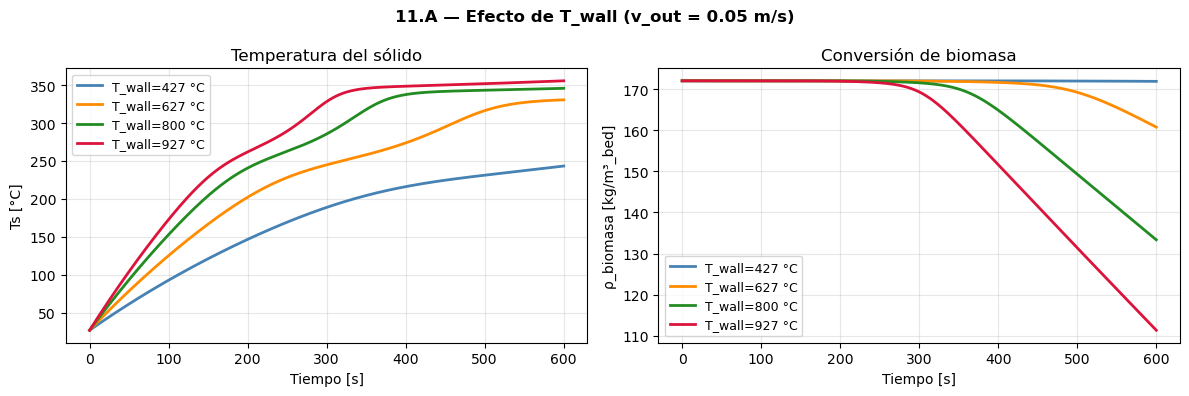

In [67]:
V_OUT_REF = 0.05    # [m/s]  venteo intermedio (referencia paramétrica)
T_MAX_PAR = 600.0   # [s]

T_wall_values = [700.0, 900.0, 1073.15, 1200.0]   # [K]
colors_tw     = ["steelblue", "darkorange", "forestgreen", "crimson"]

results_tw = []
for Tw in T_wall_values:
    tbc = build_thermal_bc_config(
        mode="fixed_twall", Di=Di, Do=Do, e_wall=e_wall,
        T_wall=Tw, k_wall=k_wall, rho_wall=rho_wall, Cp_wall=Cp_wall,
    )
    bc  = build_bc_config(n_comp=nc, P_out_bar=P_out, v_out=V_OUT_REF)
    par = {**params_base, "bc_config": bc, "thermal_bc_config": tbc}
    t_, _, g_ = run_step(sv0=sv0, t_max=T_MAX_PAR, params=par,
                         rtol=1e-5, atol=1e-7, n_sec=5, show_progress=False)
    results_tw.append((f"T_wall={Tw-273.15:.0f} °C", t_, g_))
    print(f"  T_wall={Tw-273.15:.0f} °C — Ts_final={g_._Ts_results[-1,0]-273.15:.0f} °C  "
          f"ρ_bio_final={g_._rho_solid_results[-1,0,0]:.1f} kg/m³")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for (lbl, t_, g_), col in zip(results_tw, colors_tw):
    axes[0].plot(t_, g_._Ts_results[:, 0] - 273.15, color=col, lw=2, label=lbl)
    axes[1].plot(t_, g_._rho_solid_results[:, 0, 0], color=col, lw=2, label=lbl)
axes[0].set(xlabel="Tiempo [s]", ylabel="Ts [°C]", title="Temperatura del sólido")
axes[1].set(xlabel="Tiempo [s]", ylabel="ρ_biomasa [kg/m³_bed]", title="Conversión de biomasa")
for ax in axes: ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
fig.suptitle("11.A — Efecto de T_wall (v_out = 0.05 m/s)", fontweight="bold")
fig.tight_layout(); plt.show()

### 11.B — Efecto del contenido de humedad (mc_wb)

Con mc_wb alto el secado consume energía antes de que llegue la pirólisis.
Con mc_wb ≈ 0 la biomasa entra seca y la pirólisis arranca antes.
Se observan la evolución de Ts y la composición del gas al final de la simulación.

  mc_wb=0 % — Ts_final=350 °C
  mc_wb=15 % — Ts_final=346 °C
  mc_wb=30 % — Ts_final=338 °C


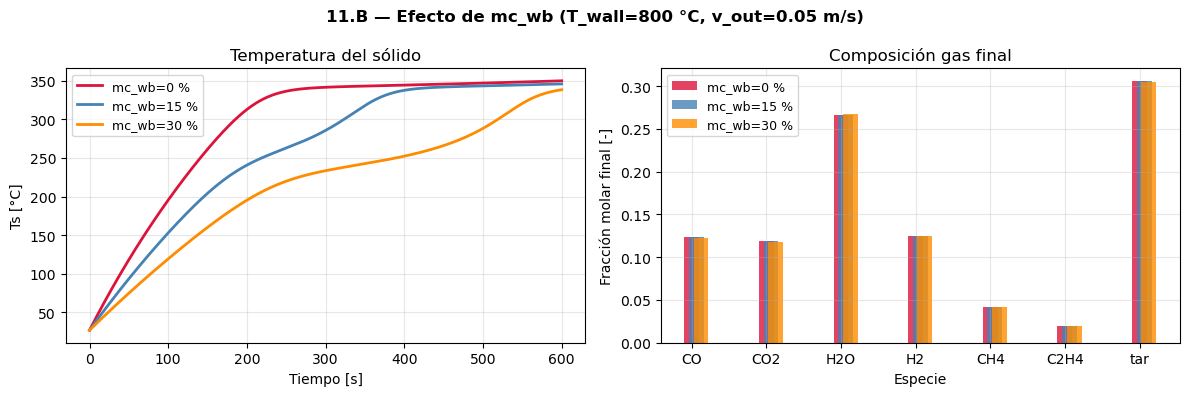

In [68]:
mc_wb_values = [0.0, 0.15, 0.30]
colors_mc    = ["crimson", "steelblue", "darkorange"]

bc_ref  = build_bc_config(n_comp=nc, P_out_bar=P_out, v_out=V_OUT_REF)
tbc_ref = build_thermal_bc_config(
    mode="fixed_twall", Di=Di, Do=Do, e_wall=e_wall,
    T_wall=T_wall, k_wall=k_wall, rho_wall=rho_wall, Cp_wall=Cp_wall,
)
results_mc = []
for mc in mc_wb_values:
    rho_moi_mc = rho_bio_dry * mc / (1 - mc) if mc < 1 else 0.0
    ic = build_initial_c_config(
        P_init=P_out, Tg_init=T_init, Ts_init=T_init, y_init=y0,
        rho_biomass_init=rho_bio_dry, rho_char_init=rho_char_0,
        rho_moisture_init=rho_moi_mc,
        n_comp=nc, N=N, prop_gas=prop_gas, epsi_r=epsi_r, gas_T_ref=gas_T_ref,
    )
    par = {**params_base, "bc_config": bc_ref, "thermal_bc_config": tbc_ref}
    t_, _, g_ = run_step(sv0=ic["sv0"], t_max=T_MAX_PAR, params=par,
                         rtol=1e-5, atol=1e-7, n_sec=5, show_progress=False)
    results_mc.append((f"mc_wb={mc*100:.0f} %", t_, g_))
    print(f"  mc_wb={mc*100:.0f} % — Ts_final={g_._Ts_results[-1,0]-273.15:.0f} °C")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for (lbl, t_, g_), col in zip(results_mc, colors_mc):
    axes[0].plot(t_, g_._Ts_results[:, 0] - 273.15, color=col, lw=2, label=lbl)
    y_fin = g_._y_results[-1, :, 0]
    sp_show = [s for s in species if y_fin[species.index(s)] > 1e-3]
    x_pos = [i + [0, 0.25, 0.5][results_mc.index((lbl, t_, g_))] * 0.25 for i in range(len(sp_show))]
    axes[1].bar(x_pos, [y_fin[species.index(s)] for s in sp_show],
                width=0.2, color=col, label=lbl, alpha=0.8)
axes[0].set(xlabel="Tiempo [s]", ylabel="Ts [°C]", title="Temperatura del sólido")
axes[1].set(xlabel="Especie", ylabel="Fracción molar final [-]", title="Composición gas final")
axes[1].set_xticks(range(len(sp_show))); axes[1].set_xticklabels(sp_show)
for ax in axes: ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
fig.suptitle("11.B — Efecto de mc_wb (T_wall=800 °C, v_out=0.05 m/s)", fontweight="bold")
fig.tight_layout(); plt.show()

### 11.C — Agotamiento de la biomasa (T_MAX)

¿Cuándo se agota la biomasa? Se extiende la simulación hasta 1800 s para observar
si ρ_biomasa → 0 antes del final. Cuando el sólido se agota, la pirólisis se detiene
y el reactor funciona como un simple calentador de gas.

  T_MAX=600 s — ρ_bio_final=133.34  ρ_char_final=9.05 kg/m³
  T_MAX=1200 s — ρ_bio_final=40.90  ρ_char_final=30.68 kg/m³
  T_MAX=1800 s — ρ_bio_final=0.00  ρ_char_final=40.20 kg/m³


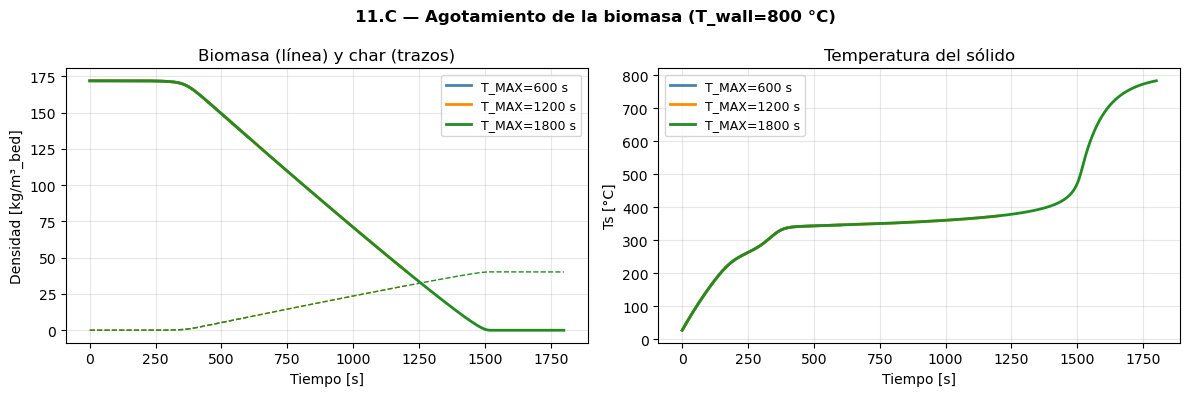

In [69]:
T_max_values = [600.0, 1200.0, 1800.0]   # [s]
colors_tm    = ["steelblue", "darkorange", "forestgreen"]

bc_ref2  = build_bc_config(n_comp=nc, P_out_bar=P_out, v_out=V_OUT_REF)
tbc_ref2 = build_thermal_bc_config(
    mode="fixed_twall", Di=Di, Do=Do, e_wall=e_wall,
    T_wall=T_wall, k_wall=k_wall, rho_wall=rho_wall, Cp_wall=Cp_wall,
)
par_ref2 = {**params_base, "bc_config": bc_ref2, "thermal_bc_config": tbc_ref2}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for tmax, col in zip(T_max_values, colors_tm):
    t_, _, g_ = run_step(sv0=sv0, t_max=tmax, params=par_ref2,
                         rtol=1e-5, atol=1e-7, n_sec=3, show_progress=False)
    lbl = f"T_MAX={tmax:.0f} s"
    axes[0].plot(t_, g_._rho_solid_results[:, 0, 0], color=col, lw=2, label=lbl)  # biomasa
    axes[0].plot(t_, g_._rho_solid_results[:, 1, 0], color=col, lw=1, ls="--")     # char
    axes[1].plot(t_, g_._Ts_results[:, 0] - 273.15,  color=col, lw=2, label=lbl)
    print(f"  T_MAX={tmax:.0f} s — ρ_bio_final={g_._rho_solid_results[-1,0,0]:.2f}  "
          f"ρ_char_final={g_._rho_solid_results[-1,1,0]:.2f} kg/m³")

axes[0].set(xlabel="Tiempo [s]", ylabel="Densidad [kg/m³_bed]",
            title="Biomasa (línea) y char (trazos)")
axes[1].set(xlabel="Tiempo [s]", ylabel="Ts [°C]", title="Temperatura del sólido")
for ax in axes: ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
fig.suptitle("11.C — Agotamiento de la biomasa (T_wall=800 °C)", fontweight="bold")
fig.tight_layout(); plt.show()

### 11.D — Barrido de _out — límite batch sellado

¿A partir de qué _out la presión del semibatch se vuelve indistinguible del batch sellado?
Se muestran la presión y la velocidad de venteo para 4 valores de _out.

  v_out=0.00 (batch)   P_max=224.151 bar
  v_out=0.01 m/s       P_max=3.603 bar
  v_out=0.05 m/s       P_max=1.963 bar
  v_out=0.50 m/s       P_max=1.172 bar


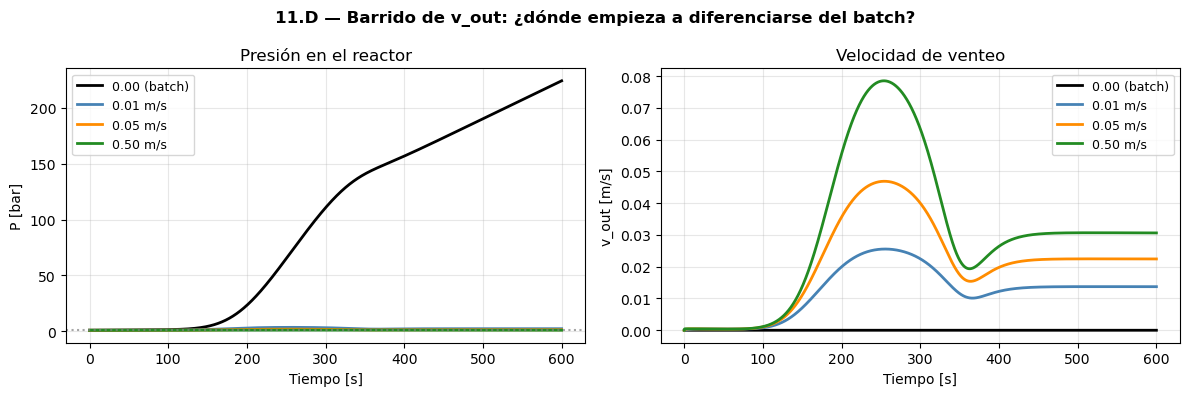

In [70]:
v_out_values = [0.0, 0.01, 0.05, 0.50]
labels_vo    = ["0.00 (batch)", "0.01 m/s", "0.05 m/s", "0.50 m/s"]
colors_vo    = ["black", "steelblue", "darkorange", "forestgreen"]

tbc_ref3 = build_thermal_bc_config(
    mode="fixed_twall", Di=Di, Do=Do, e_wall=e_wall,
    T_wall=T_wall, k_wall=k_wall, rho_wall=rho_wall, Cp_wall=Cp_wall,
)
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)
for vo, lbl, col in zip(v_out_values, labels_vo, colors_vo):
    bc_vo  = build_bc_config(n_comp=nc, P_out_bar=P_out, v_out=vo)
    par_vo = {**params_base, "bc_config": bc_vo, "thermal_bc_config": tbc_ref3}
    t_, _, g_ = run_step(sv0=sv0, t_max=T_MAX_PAR, params=par_vo,
                         rtol=1e-5, atol=1e-7, n_sec=5, show_progress=False)
    axes[0].plot(t_, g_._P_results[:, 0],    color=col, lw=2, label=lbl)
    axes[1].plot(t_, g_._v_out_results,       color=col, lw=2, label=lbl)
    print(f"  v_out={lbl:<14} P_max={float(g_._P_results.max()):.3f} bar")

axes[0].axhline(P_out, ls=":", color="gray", alpha=0.7)
axes[0].set(xlabel="Tiempo [s]", ylabel="P [bar]", title="Presión en el reactor")
axes[1].set(xlabel="Tiempo [s]", ylabel="v_out [m/s]", title="Velocidad de venteo")
for ax in axes: ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
fig.suptitle("11.D — Barrido de v_out: ¿dónde empieza a diferenciarse del batch?",
             fontweight="bold")
fig.tight_layout(); plt.show()

### 11.E — Efecto de la presión de consigna (P_out)

Se varía la presión de referencia de la válvula de alivio (P_out).
Con P_out > P_atm el reactor opera a sobrepresión: el gas se acumula hasta superar
ese umbral, lo que modifica las concentraciones absolutas y puede afectar a la cinética.

  P_out=1.01 bar (atm)  P_max=1.963 bar  Ts_final=346 °C
  P_out=2.0 bar         P_max=3.164 bar  Ts_final=346 °C
  P_out=5.0 bar         P_max=6.433 bar  Ts_final=346 °C


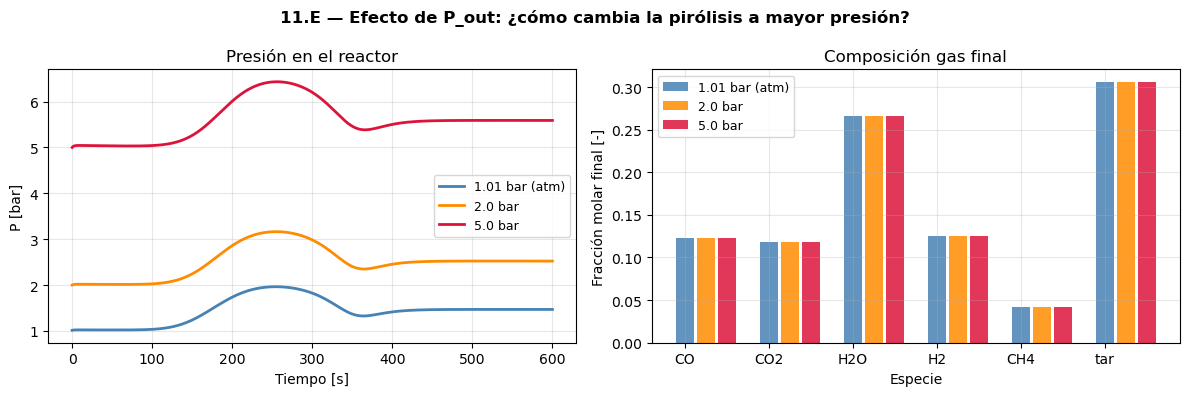

In [71]:
P_out_values  = [1.01325, 2.0, 5.0]   # [bar]
labels_po     = ["1.01 bar (atm)", "2.0 bar", "5.0 bar"]
colors_po     = ["steelblue", "darkorange", "crimson"]

tbc_ref4 = build_thermal_bc_config(
    mode="fixed_twall", Di=Di, Do=Do, e_wall=e_wall,
    T_wall=T_wall, k_wall=k_wall, rho_wall=rho_wall, Cp_wall=Cp_wall,
)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for po, lbl, col in zip(P_out_values, labels_po, colors_po):
    # Condición inicial a P_out (presurizado desde el inicio)
    ic_po = build_initial_c_config(
        P_init=po, Tg_init=T_init, Ts_init=T_init, y_init=y0,
        rho_biomass_init=rho_bio_0, rho_char_init=rho_char_0,
        rho_moisture_init=rho_moi_0,
        n_comp=nc, N=N, prop_gas=prop_gas, epsi_r=epsi_r, gas_T_ref=gas_T_ref,
    )
    bc_po  = build_bc_config(n_comp=nc, P_out_bar=po, v_out=V_OUT_REF)
    par_po = {**params_base, "bc_config": bc_po, "thermal_bc_config": tbc_ref4}
    t_, _, g_ = run_step(sv0=ic_po["sv0"], t_max=T_MAX_PAR, params=par_po,
                         rtol=1e-5, atol=1e-7, n_sec=5, show_progress=False)
    axes[0].plot(t_, g_._P_results[:, 0], color=col, lw=2, label=lbl)
    y_fin = g_._y_results[-1, :, 0]
    sp_show = ["CO", "CO2", "H2O", "H2", "CH4", "tar"]
    axes[1].bar([i + P_out_values.index(po)*0.25 for i in range(len(sp_show))],
                [y_fin[species.index(s)] for s in sp_show],
                width=0.22, color=col, label=lbl, alpha=0.85)
    print(f"  P_out={lbl:<15} P_max={float(g_._P_results.max()):.3f} bar  "
          f"Ts_final={g_._Ts_results[-1,0]-273.15:.0f} °C")

axes[0].set(xlabel="Tiempo [s]", ylabel="P [bar]", title="Presión en el reactor")
axes[1].set(xlabel="Especie", ylabel="Fracción molar final [-]", title="Composición gas final")
axes[1].set_xticks(range(len(sp_show))); axes[1].set_xticklabels(sp_show)
for ax in axes: ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
fig.suptitle("11.E — Efecto de P_out: ¿cómo cambia la pirólisis a mayor presión?",
             fontweight="bold")
fig.tight_layout(); plt.show()